# Working with complicated dataset

Your name: Julie Nguyen

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [1]:
### Your code here . . .

In [2]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"

text = requests.get(url).text.split("\n")

for line in text:
    if "# Fields:" in line:
        fields_line = line

columns = fields_line.split(": ")[1].split(", ")

df = pd.read_csv(url, comment="#", header=None)

df = df.iloc[:, :len(columns)]

df.columns = columns

df = df.drop("query acc.ver", axis=1)

df = df.set_index("subject acc.ver")

df.head()

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,"publications"",,,,,,,,,,,,,,,\r"
subject acc.ver,,,,,,,,,,,,,
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NP_904328.1,100.000,318.0,0.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,"1,487",9
AGK29621.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,"17,947",47
YP_220563.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,"12,106",13
ACM24502.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,99.69,"2,319",41


### Question 2
What is the average number of publications?

In [3]:
### Your code here . . .
df.columns

Index(['% identity', 'alignment length', 'mismatches', 'gap opens', 'q. start',
       'q. end', 's. start', 's. end', 'evalue', 'bit score', '% positives',
       'bonds', 'publications",,,,,,,,,,,,,,,\r'],
      dtype='str')

In [4]:
pub = df.iloc[:, -1]
pub = pd.to_numeric(pub, errors="coerce")
pub.mean()

np.float64(26.989690721649485)

### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [5]:
### Your code here . . .

In [6]:
bonds = pd.to_numeric(df.iloc[:, -2], errors="coerce")
df[bonds > 15000].index.tolist()

[]

### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

In [7]:
### Your code here . . .

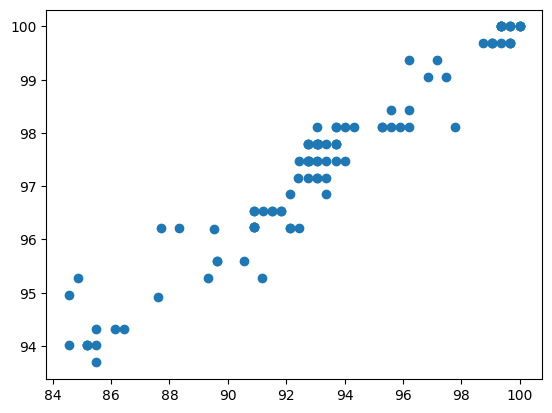

In [8]:
import matplotlib.pyplot as plt

plt.scatter(df["% identity"], df["% positives"])
plt.show()

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [9]:
### Your code here . . .

In [10]:
protein_url = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv"

protein_df = pd.read_csv(protein_url)

df = df.merge(protein_df, left_index=True, right_on="Protein", how="left")

df = df.set_index("Protein")

df.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,"publications"",,,,,,,,,,,,,,,\r",Unnamed: 0,Source
Protein,,,,,,,,,,,,,,,
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NP_904328.1,100.000,318.0,0.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,"1,487",9,0.0,RefSeq
AGK29621.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,"17,947",47,NaN,NaN
YP_220563.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,"12,106",13,2.0,GenPept
ACM24502.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,99.69,"2,319",41,NaN,NaN
